In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
DATA_PATH = "/content/drive/MyDrive/datasets/store_sales"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
train['date'] = pd.to_datetime(train['date'])


In [4]:
daily_sales = (
    train
    .groupby('date')['sales']
    .sum()
    .reset_index()
    .sort_values('date')
)


In [10]:
split_date = "2017-01-01"

train_ts = daily_sales[daily_sales['date'] < split_date].copy()
test_ts  = daily_sales[daily_sales['date'] >= split_date].copy()


In [11]:
test_ts.loc[:, 'naive_pred'] = train_ts['sales'].iloc[-1]


In [12]:
window = 7  # 7 günlük hareketli ortalama

moving_avg = train_ts['sales'].rolling(window=window).mean().iloc[-1]
test_ts.loc[:, 'ma_pred'] = moving_avg


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

naive_mae, naive_rmse = evaluate(test_ts['sales'], test_ts['naive_pred'])
ma_mae, ma_rmse = evaluate(test_ts['sales'], test_ts['ma_pred'])

print("Naive MAE:", naive_mae, "RMSE:", naive_rmse)
print("Moving Avg MAE:", ma_mae, "RMSE:", ma_rmse)


Naive MAE: 273791.5759241837 RMSE: 310699.23605658766
Moving Avg MAE: 221071.40737158756 RMSE: 253498.18046198785


Baseline Forecast Performans Karşılaştırması

Naive Forecast ve 7 günlük Hareketli Ortalama (Moving Average) yöntemleri, test verisi üzerinde MAE ve RMSE metrikleri kullanılarak karşılaştırılmıştır.

Naive Forecast

MAE: 273,791

RMSE: 310,699

Moving Average (7 gün)

MAE: 221,071

RMSE: 253,498

Elde edilen sonuçlara göre, 7 günlük hareketli ortalama yöntemi, Naive Forecast yaklaşımına kıyasla hem MAE hem de RMSE metriklerinde daha düşük hata değerleri üretmiştir. Bu durum, kısa dönemli satış dalgalanmalarının Moving Average yöntemi ile daha iyi yumuşatıldığını ve tahmin doğruluğunun arttığını göstermektedir.

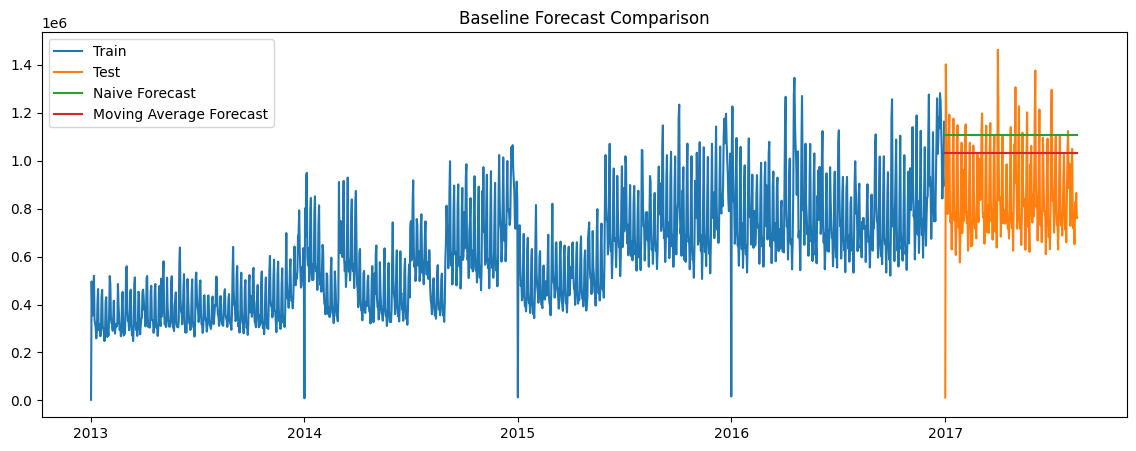

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(train_ts['date'], train_ts['sales'], label="Train")
plt.plot(test_ts['date'], test_ts['sales'], label="Test")
plt.plot(test_ts['date'], test_ts['naive_pred'], label="Naive Forecast")
plt.plot(test_ts['date'], test_ts['ma_pred'], label="Moving Average Forecast")
plt.legend()
plt.title("Baseline Forecast Comparison")
plt.show()


Yukarıdaki grafikte, günlük toplam satış verisi için eğitim (train) ve test dönemleri ile birlikte iki farklı baseline tahmin yöntemi karşılaştırılmıştır: Naive Forecast ve 7 günlük Hareketli Ortalama (Moving Average).

Naive Forecast yöntemi, eğitim setindeki son gözlemi test dönemindeki tüm günler için sabit bir tahmin olarak kullanmaktadır. Bu yaklaşım, satış verisindeki genel seviye hakkında temel bir referans sağlasa da, test dönemindeki dalgalanmaları ve trend değişimlerini yakalamakta yetersiz kalmaktadır.

7 günlük Hareketli Ortalama yöntemi ise kısa dönemli dalgalanmaları yumuşatarak, Naive Forecast’e kıyasla test dönemine daha dengeli bir tahmin sunmaktadır. Grafik incelendiğinde, Moving Average tahminlerinin test verisinin genel seviyesine daha yakın seyrettiği görülmektedir.

Ancak her iki baseline yöntemi de satış verisinde mevcut olan trend, mevsimsellik ve ani değişimleri yeterince modelleyememektedir. Bu durum, daha gelişmiş zaman serisi modelleme yaklaşımlarının (örneğin SARIMA veya makine öğrenmesi tabanlı modeller) gerekliliğini ortaya koymaktadır.

## Model Seçim Kararı

Baseline tahmin yöntemlerinden elde edilen sonuçlar değerlendirildiğinde, daha yüksek tahmin performansı elde edebilmek için makine öğrenmesi tabanlı modellere geçilmesine karar verilmiştir.  
Bu kapsamda, gecikmeli (lag) değişkenler ve istatistiksel özniteliklerin modele dahil edilebilmesi, doğrusal olmayan ilişkilerin yakalanabilmesi ve karmaşık zaman serisi yapılarının daha iyi modellenebilmesi nedeniyle gradyan artırma tabanlı yaklaşımlar (XGBoost / LightGBM) tercih edilmiştir.
